In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import xarray as xr
from IPython.display import Video

import qg_atm as qg

In [2]:
print("=== Optimal Range ===")
KM = 1_000

N, M, p = 256, 100, 3
L = 1
alpha = (L*KM)/qg.R_planet

def optimal_min(alpha, n, m, p):
    r_min = 0
    nu_min = 1/(qg.PI * n)**(2*p)
    eps_min = 0
    kappa_min = 1
    return r_min, nu_min, eps_min, kappa_min

def optimal_max(alpha, n, m, p):
    alpha_e = qg.L_edge/qg.R_planet
    kappa_e = alpha/alpha_e
    r_max = np.minimum(kappa_e, N)
    nu_max = m/n**(2*p)
    eps_max = 1
    kappa_max = n
    return r_max, nu_max, eps_max, kappa_max

def optimal_scale(param, alpha, n, m, p):
    r_norm, nu_norm, eps_norm, kappa_norm = param
    r_max, nu_max, eps_max, kappa_max = optimal_max(alpha, n, m, p)
    return r_max * r_norm, nu_max * nu_norm, eps_max * eps_norm, kappa_max * kappa_norm

# r, nu, eps, kappa = optimal_scale((r, nu, eps, kappa), alpha, N, M, p)
r_m, nu_m, eps_m, kappa_m = optimal_max(alpha, N, M, p)

# print(r, nu, eps)
print(f"{r_m:.1e} {nu_m:.1e} {eps_m:.1e}")


=== Optimal Range ===
1.0e+00 3.6e-13 1.0e+00


In [24]:
config = {
    'experiment': "beta-effect",
    'n_iter': 10,
    't_iter': 10,
    'descript': {
        'N': 256,
        'M': 100,
        'kappa': 0,
        'p': 2,
        'nu': 4e-8,
        'r': 1e-2,
        'epsilon': 1,
        'beta': 2e-1,
        'kf': 16,
        'dkf': 1,
        'initial': 'zero',
        'forcing': 'normal',
    },
    'pds_args': {
        'q_range': "end", 
        'u_range': "end", 
        'q_cmap':"balance"
    },
}

model = qg.Driver(qg.Config(**config))
print(model.devices)

[CudaDevice(id=0)]


In [25]:
ds = model.run()

KE: 2.08e-01, VE: 4.66e+00, RB: 1.50 | time-iter =   2.71  s | 10/10 [00:30<00:00]
Preparing dataset...


100%|█████████████████████████████████████████████████████| 101/101 [00:00<00:00, 4015.17it/s]


Saving animation of q...
Saving animation of u...
Saving animation of e_spec...
Saving animation of z_spec...


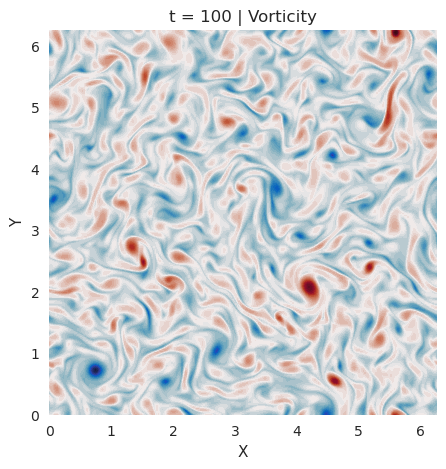

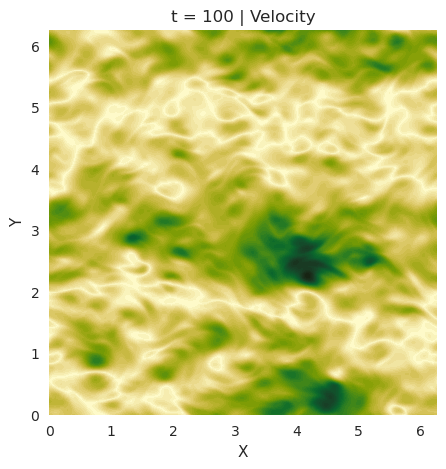

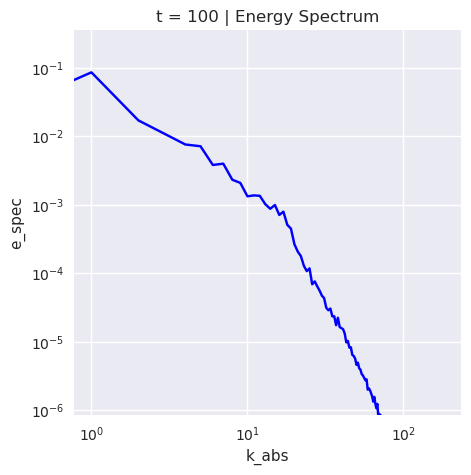

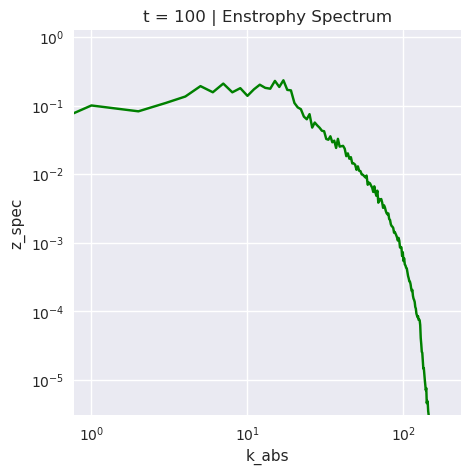

In [26]:
model.config.print_dataset = "std"
model.print_dataset(ds)

In [33]:
Video("data/test/atm-q.mp4", embed=True)

In [ ]:
Video("data/test/atm-u.mp4", embed=True)

In [ ]:
Video("data/test/atm-e_spec.mp4", embed=True)

In [ ]:
Video("data/test/atm-z_spec.mp4", embed=True)